# 04 Detect Peak (No Peak File)

sEMG respiratory 신호에서 직접 peak를 검출하고, apnea 구간을 제외한 뒤 peak-to-peak breathing cycle을 정의합니다.


In [98]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks

sns.set_theme(style='whitegrid')

# ---------------------------
# Data / Signal configuration
# ---------------------------
RAW_DIR = Path('/home/jhkim/NAVA/02_YOLO/data/1_Refined_Raw')
PEAK_DIR = Path('/home/jhkim/NAVA/02_YOLO/data/2_Refined_Peaks')
PATIENT_ID = '04'  # e.g. '03', 3, 'patient_03'
FS = 100  # Hz

# ---------------------------
# Step parameters (strictly requested ranges)
# ---------------------------
BASELINE_WIN_SEC = 20.0  # moving median
SMOOTH_WIN_SEC = 0.3     # moving average (0.3~0.5 sec)
LOCAL_STD_WIN_SEC = 1.5  # local std (2~5 sec)
APNEA_MIN_SEC = 5.0     # low-variance run length to mark apnea
MIN_PEAK_DIST_SEC = 0.5  # minimum peak distance
MIN_BREATH_SEC = 0.6     # optional physiological lower bound
MAX_BREATH_SEC = 10.0    # optional physiological upper bound

# Relative (non-absolute) thresholds
LOW_STD_QUANTILE = 0.10
PROM_FACTOR = 0.8

# Actual peak visualization pad
ACTUAL_PEAK_PAD_RATIO = 0.1



In [99]:
def normalize_patient_id(v):
    s = str(v).strip()
    m = re.search(r'(\d+)', s)
    if not m:
        raise ValueError(f'Invalid patient id: {v!r}')
    return f"{int(m.group(1)):02d}"


def rolling_centered_median(x, win):
    return pd.Series(x).rolling(window=win, center=True, min_periods=1).median().to_numpy()


def rolling_centered_mean(x, win):
    return pd.Series(x).rolling(window=win, center=True, min_periods=1).mean().to_numpy()


def rolling_centered_std(x, win):
    return pd.Series(x).rolling(window=win, center=True, min_periods=1).std(ddof=0).to_numpy()


def mark_long_runs(mask: np.ndarray, min_len: int) -> np.ndarray:
    out = np.zeros_like(mask, dtype=bool)
    n = len(mask)
    i = 0
    while i < n:
        if not mask[i]:
            i += 1
            continue
        j = i
        while j < n and mask[j]:
            j += 1
        if j - i >= min_len:
            out[i:j] = True
        i = j
    return out


def infer_time_seconds(ts: np.ndarray, fs: float) -> np.ndarray:
    ts = np.asarray(ts, dtype=float)
    if len(ts) < 3:
        return np.arange(len(ts), dtype=float) / fs

    d = np.diff(ts)
    d = d[np.isfinite(d) & (d > 0)]
    if len(d) == 0:
        return np.arange(len(ts), dtype=float) / fs

    dt = float(np.median(d))
    if 0.005 <= dt <= 0.02:
        return ts  # already seconds
    if 5.0 <= dt <= 20.0:
        return ts / 1000.0  # milliseconds
    if 0.5 <= dt <= 2.0:
        return ts / fs  # sample index

    return np.arange(len(ts), dtype=float) / fs


def resolve_columns(df: pd.DataFrame):
    original_cols = list(df.columns)
    df = df.copy()
    df.columns = [str(c).strip().lower() for c in df.columns]

    ts_candidates = ['timestamp', 'time', 't', 'ts']
    resp_candidates = ['resp', 'respiratory', 'semg', 'semg_resp', 'resp_signal', 'breath']
    edi_candidates = ['edi', 'edi_signal']

    ts_col = next((c for c in ts_candidates if c in df.columns), None)
    resp_col = next((c for c in resp_candidates if c in df.columns), None)
    edi_col = next((c for c in edi_candidates if c in df.columns), None)

    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

    if ts_col is None:
        if len(num_cols) >= 1:
            ts_col = num_cols[0]
        else:
            raise ValueError(f'No numeric timestamp-like column found. columns={original_cols}')

    signal_cols = [c for c in num_cols if c != ts_col]

    if resp_col is None and edi_col is not None:
        resp_col = edi_col
    elif edi_col is None and resp_col is not None:
        edi_col = resp_col
    elif resp_col is None and edi_col is None:
        if len(signal_cols) >= 2:
            resp_col, edi_col = signal_cols[0], signal_cols[1]
        elif len(signal_cols) == 1:
            resp_col = signal_cols[0]
            edi_col = signal_cols[0]
        else:
            raise ValueError(
                'Could not resolve signal columns. '
                f'columns={original_cols}, numeric={num_cols}'
            )

    shared_signal = (resp_col == edi_col)
    return ts_col, resp_col, edi_col, shared_signal, df


def load_patient_frame(raw_dir: Path, patient_id: str):
    pid = normalize_patient_id(patient_id)
    path = raw_dir / f'{pid}.xlsx'
    if not path.exists():
        raise FileNotFoundError(f'Missing file: {path}')

    raw = pd.read_excel(path)
    ts_col, resp_col, edi_col, shared_signal, raw = resolve_columns(raw)

    x = raw[[ts_col, resp_col, edi_col]].copy()
    x = x.dropna().reset_index(drop=True)
    x.columns = ['timestamp', 'resp', 'edi']
    x['timestamp'] = pd.to_numeric(x['timestamp'], errors='coerce')
    x['resp'] = pd.to_numeric(x['resp'], errors='coerce')
    x['edi'] = pd.to_numeric(x['edi'], errors='coerce')
    x = x.dropna().reset_index(drop=True)

    t_sec = infer_time_seconds(x['timestamp'].to_numpy(), FS)
    x['time_sec'] = t_sec

    meta = {
        'timestamp_col': ts_col,
        'resp_col': resp_col,
        'edi_col': edi_col,
        'shared_signal': shared_signal,
    }
    return path, x, meta


def load_actual_peak_indices(peak_dir: Path, patient_id: str, raw_timestamps: np.ndarray):
    pid = normalize_patient_id(patient_id)

    candidates = [
        peak_dir / f'{pid}.xlsx',
        peak_dir / f'patient_{pid}.xlsx',
        peak_dir / f'refined_peaks_patient_{pid}.xlsx',
    ]
    path = next((c for c in candidates if c.exists()), None)

    if path is None:
        glob_hit = sorted(peak_dir.glob(f'*{pid}*.xlsx'))
        if len(glob_hit) == 1:
            path = glob_hit[0]
        else:
            return peak_dir / f'refined_peaks_patient_{pid}.xlsx', np.array([], dtype=int)

    peaks = pd.read_excel(path)
    peaks.columns = [str(c).strip().lower() for c in peaks.columns]

    ts_col = next((c for c in ['timestamp', 'time', 't', 'ts'] if c in peaks.columns), None)
    if ts_col is None:
        num_cols = [c for c in peaks.columns if pd.api.types.is_numeric_dtype(peaks[c])]
        if len(num_cols) == 0:
            return path, np.array([], dtype=int)
        ts_col = num_cols[0]

    peak_ts = pd.to_numeric(peaks[ts_col], errors='coerce').dropna().to_numpy(dtype=float)
    if len(peak_ts) == 0:
        return path, np.array([], dtype=int)

    peak_ts = np.unique(peak_ts)
    raw_ts = np.asarray(raw_timestamps, dtype=float)

    ins = np.searchsorted(raw_ts, peak_ts)
    ins = np.clip(ins, 1, len(raw_ts) - 1)

    left = ins - 1
    right = ins
    choose_left = np.abs(peak_ts - raw_ts[left]) <= np.abs(raw_ts[right] - peak_ts)
    nearest = np.where(choose_left, left, right)

    nearest = nearest[(nearest >= 0) & (nearest < len(raw_ts))]
    return path, np.unique(nearest.astype(int))




In [100]:
# ---------------------------
# Load data
# ---------------------------
raw_path, df, signal_meta = load_patient_frame(RAW_DIR, PATIENT_ID)

resp_raw = df['resp'].to_numpy(dtype=float)
edi = df['edi'].to_numpy(dtype=float)
t_sec = df['time_sec'].to_numpy(dtype=float)
raw_ts = df['timestamp'].to_numpy(dtype=float)

actual_peak_path, actual_peak_idx = load_actual_peak_indices(PEAK_DIR, PATIENT_ID, raw_ts)

# ---------------------------
# 1) Baseline removal (20 s moving median)
# ---------------------------
baseline_win = int(BASELINE_WIN_SEC * FS)
baseline = rolling_centered_median(resp_raw, baseline_win)
resp_detrended = resp_raw - baseline

# ---------------------------
# 2) Light smoothing (0.3~0.5 s moving average)
# ---------------------------
smooth_win = int(SMOOTH_WIN_SEC * FS)
resp_proc = rolling_centered_mean(resp_detrended, smooth_win)

# ---------------------------
# 3) Apnea masking (local std + long low-variance run)
# ---------------------------
local_std_win = int(LOCAL_STD_WIN_SEC * FS)
local_std = rolling_centered_std(resp_proc, local_std_win)

std_ref = local_std[np.isfinite(local_std)]
low_std_thr = np.quantile(std_ref, LOW_STD_QUANTILE)
low_var = local_std <= low_std_thr
apnea_mask = mark_long_runs(low_var, min_len=int(APNEA_MIN_SEC * FS))

# Padding used to place actual peaks slightly above signal
sig_range = float(np.nanpercentile(resp_proc, 95) - np.nanpercentile(resp_proc, 5))
actual_peak_pad = max(sig_range * ACTUAL_PEAK_PAD_RATIO, 1e-6)

print(f'Loaded: {raw_path.name}')
print(f'N samples: {len(df):,}  | Duration: {t_sec[-1] - t_sec[0]:.1f} sec')
print(
    'Columns used -> '
    f"timestamp: {signal_meta['timestamp_col']}, "
    f"resp(detection): {signal_meta['resp_col']}, "
    f"edi(plot): {signal_meta['edi_col']}"
)
if signal_meta['shared_signal']:
    print('Note: respiratory detection signal is the same Edi signal (single-signal input).')
print(f'Apnea ratio: {apnea_mask.mean() * 100:.2f}%')
print(f'Actual peak file: {actual_peak_path.name} | Actual peaks loaded: {len(actual_peak_idx)}')



Loaded: 04.xlsx
N samples: 300,000  | Duration: 3000.0 sec
Columns used -> timestamp: timestamp, resp(detection): edi, edi(plot): edi
Note: respiratory detection signal is the same Edi signal (single-signal input).
Apnea ratio: 0.84%
Actual peak file: refined_peaks_patient_04.xlsx | Actual peaks loaded: 2102


In [101]:
# ---------------------------
# 4) Peak detection (prominence-based, no fixed height)
# ---------------------------
non_apnea_std = local_std[~apnea_mask]
if len(non_apnea_std) == 0:
    raise ValueError('All samples are masked as apnea. Check local std parameters.')

prominence_min = float(np.median(non_apnea_std) * PROM_FACTOR)
peak_idx, peak_props = find_peaks(
    resp_proc,
    distance=int(MIN_PEAK_DIST_SEC * FS),
    prominence=prominence_min,
)

# Exclude apnea peaks
peak_idx = peak_idx[~apnea_mask[peak_idx]]

# Optional physiological interval filter (1~10 sec)
if len(peak_idx) >= 2:
    d = np.diff(peak_idx)
    keep = np.ones(len(peak_idx), dtype=bool)
    keep[1:] &= (d >= int(MIN_BREATH_SEC * FS)) & (d <= int(MAX_BREATH_SEC * FS))
    peak_idx = peak_idx[keep]

# ---------------------------
# 5) Breathing cycle definition (peak-to-peak)
# ---------------------------
cycles = pd.DataFrame({
    'start_peak_idx': peak_idx[:-1],
    'end_peak_idx': peak_idx[1:],
})
cycles['start_sec'] = t_sec[cycles['start_peak_idx'].to_numpy()]
cycles['end_sec'] = t_sec[cycles['end_peak_idx'].to_numpy()]
cycles['duration_sec'] = cycles['end_sec'] - cycles['start_sec']

print(f'Detected peaks: {len(peak_idx)}')
print(f'Breathing cycles (peak-to-peak): {len(cycles)}')
display(cycles.head(10))


Detected peaks: 2036
Breathing cycles (peak-to-peak): 2035


,start_peak_idx,end_peak_idx,start_sec,end_sec,duration_sec
0,328,410,470.63,471.45,0.82
1,410,533,471.45,472.68,1.23
2,533,729,472.68,474.64,1.96
3,729,973,474.64,477.08,2.44
4,973,1126,477.08,478.61,1.53
5,1126,1264,478.61,479.99,1.38
6,1264,1443,479.99,481.78,1.79
7,1443,1677,481.78,484.12,2.34
8,1677,1868,484.12,486.03,1.91
9,1868,3575,486.03,503.10,17.07


In [102]:
# ---------------------------
# Peak evaluation vs ground truth (tolerance matching)
# ---------------------------
DELTA_EVAL_MS = 140
DELTA_EVAL_SEC = DELTA_EVAL_MS / 1000.0


def evaluate_peak_detection(detected_idx: np.ndarray, gt_idx: np.ndarray, t: np.ndarray, delta_sec: float):
    detected_idx = np.sort(np.asarray(detected_idx, dtype=int))
    gt_idx = np.sort(np.asarray(gt_idx, dtype=int))

    det_t = t[detected_idx] if len(detected_idx) > 0 else np.array([], dtype=float)
    gt_t = t[gt_idx] if len(gt_idx) > 0 else np.array([], dtype=float)

    i, j = 0, 0
    tp = 0
    matched_det = []
    matched_gt = []
    matched_err_ms = []

    while i < len(det_t) and j < len(gt_t):
        dt = det_t[i] - gt_t[j]
        if abs(dt) <= delta_sec:
            tp += 1
            matched_det.append(detected_idx[i])
            matched_gt.append(gt_idx[j])
            matched_err_ms.append(dt * 1000.0)
            i += 1
            j += 1
        elif det_t[i] < gt_t[j] - delta_sec:
            i += 1
        else:
            j += 1

    fp = len(det_t) - tp
    fn = len(gt_t) - tp

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    matched_df = pd.DataFrame({
        'detected_idx': matched_det,
        'gt_idx': matched_gt,
        'detected_sec': t[np.asarray(matched_det, dtype=int)] if len(matched_det) > 0 else np.array([], dtype=float),
        'gt_sec': t[np.asarray(matched_gt, dtype=int)] if len(matched_gt) > 0 else np.array([], dtype=float),
        'error_ms': matched_err_ms,
    })

    summary = {
        'delta_eval_ms': DELTA_EVAL_MS,
        'detected_count': int(len(det_t)),
        'ground_truth_count': int(len(gt_t)),
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
    }
    return summary, matched_df


eval_summary, eval_matches = evaluate_peak_detection(
    detected_idx=peak_idx,
    gt_idx=actual_peak_idx,
    t=t_sec,
    delta_sec=DELTA_EVAL_SEC,
)

print(f"DELTA_EVAL: {DELTA_EVAL_MS} ms")
print(
    f"Detected={eval_summary['detected_count']}, GT={eval_summary['ground_truth_count']}, "
    f"TP={eval_summary['tp']}, FP={eval_summary['fp']}, FN={eval_summary['fn']}"
)
print(
    f"Precision={eval_summary['precision']:.4f}, "
    f"Recall={eval_summary['recall']:.4f}, "
    f"F1-score={eval_summary['f1_score']:.4f}"
)

display(pd.DataFrame([eval_summary]))
display(eval_matches.head(10))



DELTA_EVAL: 140 ms
Detected=2036, GT=2102, TP=1961, FP=75, FN=141
Precision=0.9632, Recall=0.9329, F1-score=0.9478


,delta_eval_ms,detected_count,ground_truth_count,tp,fp,fn,precision,recall,f1_score
0,140,2036,2102,1961,75,141,0.963163,0.932921,0.947801


,detected_idx,gt_idx,detected_sec,gt_sec,error_ms
0,328,318,470.63,470.53,100.0
1,410,399,471.45,471.34,110.0
2,533,523,472.68,472.58,100.0
3,729,722,474.64,474.57,70.0
4,1126,1131,478.61,478.66,-50.0
5,1264,1251,479.99,479.86,130.0
6,1443,1451,481.78,481.86,-80.0
7,1677,1664,484.12,483.99,130.0
8,1868,1876,486.03,486.11,-80.0
9,3575,3566,503.10,503.01,90.0


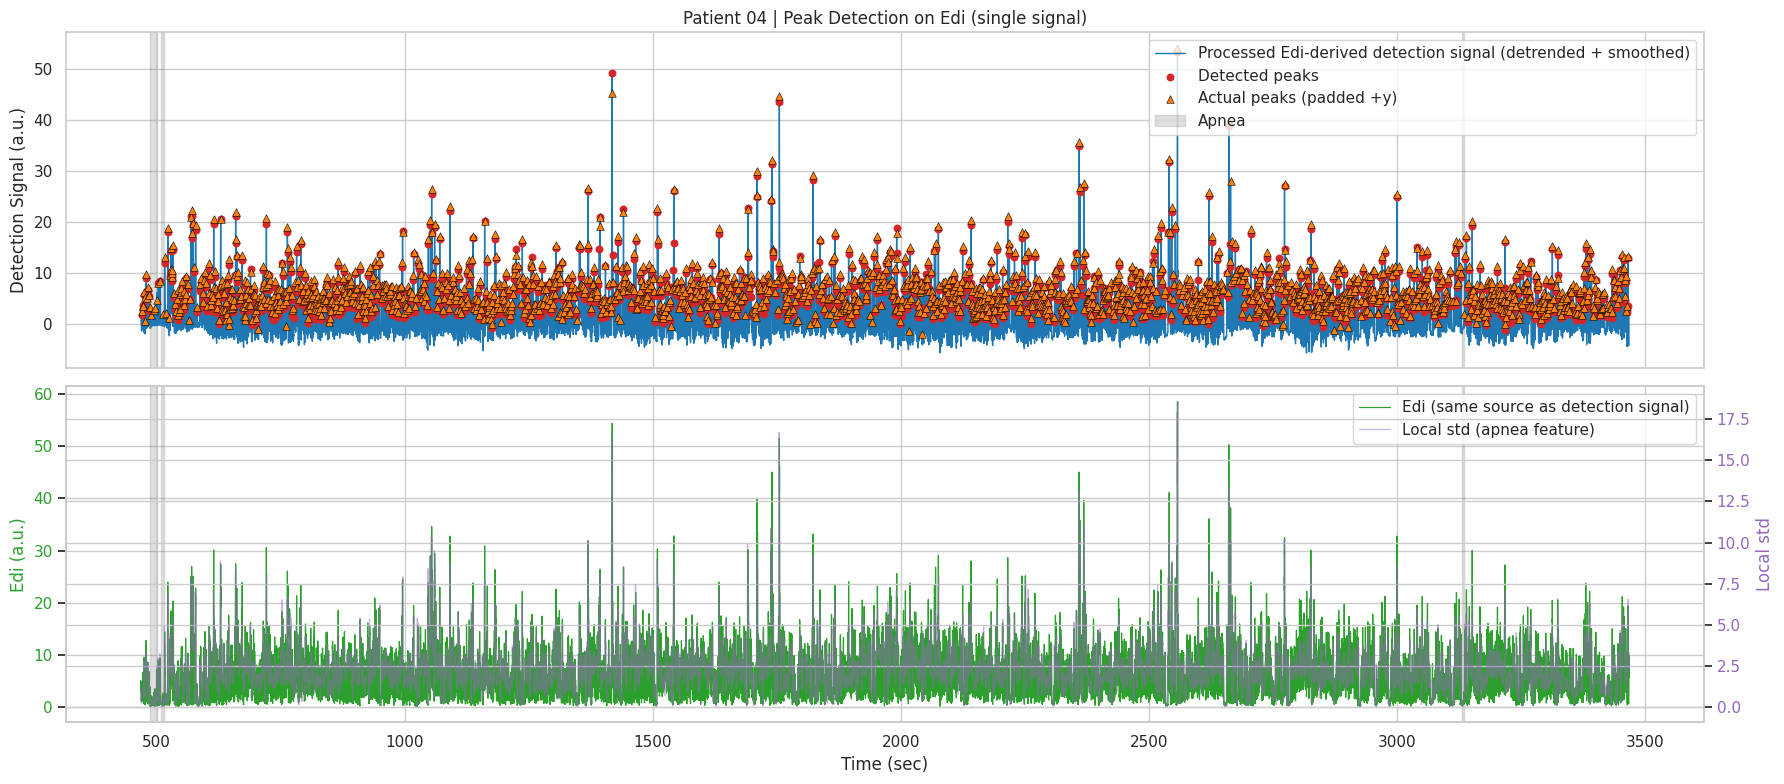

In [103]:
# ---------------------------
# 6) Visualization (aligned axes, apnea shaded)
# ---------------------------
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

# (a) Processed respiratory signal + (b) peaks
main_label = 'Processed detection signal (detrended + smoothed)'
if signal_meta['shared_signal']:
    main_label = 'Processed Edi-derived detection signal (detrended + smoothed)'

axes[0].plot(t_sec, resp_proc, lw=1.0, color='tab:blue', label=main_label)
axes[0].scatter(t_sec[peak_idx], resp_proc[peak_idx], s=22, color='tab:red', label='Detected peaks', zorder=3)

if len(actual_peak_idx) > 0:
    actual_peak_y = resp_proc[actual_peak_idx] + actual_peak_pad
    axes[0].scatter(
        t_sec[actual_peak_idx],
        actual_peak_y,
        s=30,
        marker='^',
        color='tab:orange',
        edgecolors='black',
        linewidths=0.4,
        label='Actual peaks (padded +y)',
        zorder=4,
    )

# Shade apnea regions
in_run = False
start = None
for i, flag in enumerate(apnea_mask):
    if flag and not in_run:
        in_run = True
        start = i
    elif (not flag) and in_run:
        axes[0].axvspan(t_sec[start], t_sec[i - 1], color='gray', alpha=0.25)
        axes[1].axvspan(t_sec[start], t_sec[i - 1], color='gray', alpha=0.25)
        in_run = False
if in_run:
    axes[0].axvspan(t_sec[start], t_sec[-1], color='gray', alpha=0.25, label='Apnea')
    axes[1].axvspan(t_sec[start], t_sec[-1], color='gray', alpha=0.25)
else:
    axes[0].axvspan(np.nan, np.nan, color='gray', alpha=0.25, label='Apnea')

axes[0].set_ylabel('Detection Signal (a.u.)')
if signal_meta['shared_signal']:
    axes[0].set_title(f"Patient {normalize_patient_id(PATIENT_ID)} | Peak Detection on Edi (single signal)")
else:
    axes[0].set_title(f'Patient {normalize_patient_id(PATIENT_ID)} | Peak Detection Without Peak File')
axes[0].legend(loc='upper right')

# (c) synchronized Edi + local std overlay
edi_label = 'Edi (synchronized)'
if signal_meta['shared_signal']:
    edi_label = 'Edi (same source as detection signal)'

l1 = axes[1].plot(t_sec, edi, lw=0.9, color='tab:green', label=edi_label)
axes[1].set_xlabel('Time (sec)')
axes[1].set_ylabel('Edi (a.u.)', color='tab:green')
axes[1].tick_params(axis='y', labelcolor='tab:green')

ax_std = axes[1].twinx()
l2 = ax_std.plot(t_sec, local_std, lw=0.9, color='tab:purple', alpha=0.5, label='Local std (apnea feature)')
ax_std.set_ylabel('Local std', color='tab:purple')
ax_std.tick_params(axis='y', labelcolor='tab:purple')

lines = l1 + l2
labels = [line.get_label() for line in lines]
axes[1].legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()



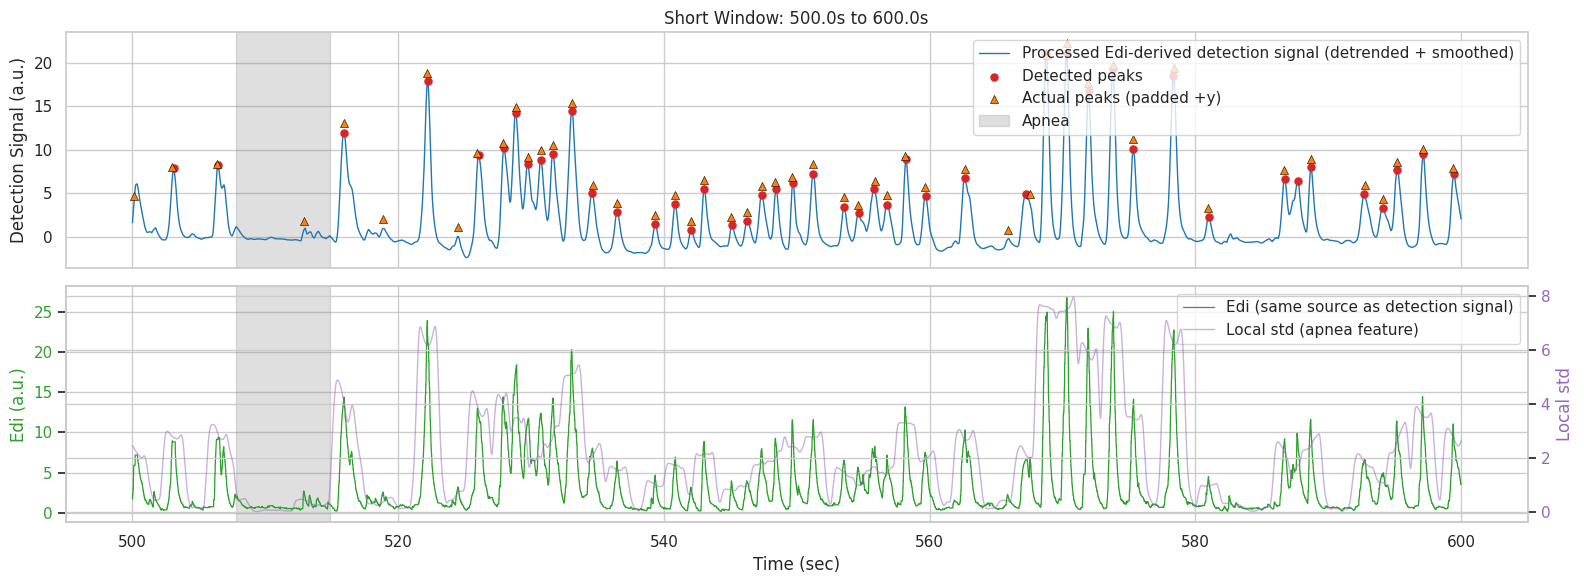

In [104]:
# ---------------------------
# Short-window visualization (set start_time, end_time in seconds)
# ---------------------------
def plot_short_window(start_time: float, end_time: float):
    if end_time <= start_time:
        raise ValueError('end_time must be greater than start_time.')

    window_mask = (t_sec >= start_time) & (t_sec <= end_time)
    if not np.any(window_mask):
        raise ValueError('No samples in the requested time window.')

    idx = np.where(window_mask)[0]
    i0, i1 = int(idx[0]), int(idx[-1])

    t_win = t_sec[i0:i1 + 1]
    resp_win = resp_proc[i0:i1 + 1]
    edi_win = edi[i0:i1 + 1]
    std_win = local_std[i0:i1 + 1]
    apnea_win = apnea_mask[i0:i1 + 1]

    peak_win = peak_idx[(peak_idx >= i0) & (peak_idx <= i1)]
    actual_peak_win = actual_peak_idx[(actual_peak_idx >= i0) & (actual_peak_idx <= i1)]

    fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

    main_label = 'Processed detection signal (detrended + smoothed)'
    if signal_meta['shared_signal']:
        main_label = 'Processed Edi-derived detection signal (detrended + smoothed)'

    axes[0].plot(t_win, resp_win, lw=1.0, color='tab:blue', label=main_label)
    axes[0].scatter(t_sec[peak_win], resp_proc[peak_win], s=26, color='tab:red', label='Detected peaks', zorder=3)

    if len(actual_peak_win) > 0:
        actual_peak_y_win = resp_proc[actual_peak_win] + actual_peak_pad
        axes[0].scatter(
            t_sec[actual_peak_win],
            actual_peak_y_win,
            s=34,
            marker='^',
            color='tab:orange',
            edgecolors='black',
            linewidths=0.4,
            label='Actual peaks (padded +y)',
            zorder=4,
        )

    # Shade apnea regions within the selected window
    in_run = False
    start = None
    for j, flag in enumerate(apnea_win):
        if flag and not in_run:
            in_run = True
            start = j
        elif (not flag) and in_run:
            axes[0].axvspan(t_win[start], t_win[j - 1], color='gray', alpha=0.25)
            axes[1].axvspan(t_win[start], t_win[j - 1], color='gray', alpha=0.25)
            in_run = False
    if in_run:
        axes[0].axvspan(t_win[start], t_win[-1], color='gray', alpha=0.25, label='Apnea')
        axes[1].axvspan(t_win[start], t_win[-1], color='gray', alpha=0.25)
    else:
        axes[0].axvspan(np.nan, np.nan, color='gray', alpha=0.25, label='Apnea')

    axes[0].set_ylabel('Detection Signal (a.u.)')
    axes[0].set_title(f'Short Window: {start_time:.1f}s to {end_time:.1f}s')
    axes[0].legend(loc='upper right')

    edi_label = 'Edi (synchronized)'
    if signal_meta['shared_signal']:
        edi_label = 'Edi (same source as detection signal)'

    l1 = axes[1].plot(t_win, edi_win, lw=0.9, color='tab:green', label=edi_label)
    axes[1].set_xlabel('Time (sec)')
    axes[1].set_ylabel('Edi (a.u.)', color='tab:green')
    axes[1].tick_params(axis='y', labelcolor='tab:green')

    ax_std = axes[1].twinx()
    l2 = ax_std.plot(t_win, std_win, lw=1.0, color='tab:purple', alpha=0.5, label='Local std (apnea feature)')
    ax_std.set_ylabel('Local std', color='tab:purple')
    ax_std.tick_params(axis='y', labelcolor='tab:purple')

    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    axes[1].legend(lines, labels, loc='upper right')

    plt.tight_layout()
    plt.show()


# Example usage: edit these two values
start_time = 500.0
end_time = start_time + 100
plot_short_window(start_time, end_time)

